In [1]:
# Imports + repo path
from __future__ import annotations

import os
import sys
from argparse import Namespace
from pathlib import Path
from typing import Tuple
import time

import numpy as np
import torch
import yaml
import matplotlib.pyplot as plt
from IPython.display import clear_output, display
from scipy.stats import gaussian_kde

REPO_ROOT = Path.cwd().resolve()
if (REPO_ROOT / 'src').exists():
    sys.path.append(str(REPO_ROOT))
else:
    # If you opened the notebook from a subdir, try to locate repo root.
    for p in Path.cwd().resolve().parents:
        if (p / 'src').exists():
            REPO_ROOT = p
            sys.path.append(str(REPO_ROOT))
            break

from src.model.energy_force_diffusion import EnergyForceDiffusion
from src.utils import dict_to_namespace

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

/home/iwe67/miniforge3/envs/drugflow/lib/python3.11/site-packages/lightning_fabric/__init__.py:41: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.


device: cuda


In [2]:
# Helpers (swiss-roll data, KDE energy, batching, plotting)

def make_swiss_roll_2d(n_samples: int, noise: float, *, seed: int = 0) -> np.ndarray:
    rng = np.random.default_rng(seed)
    t = rng.uniform(1.5 * np.pi, 4.5 * np.pi, size=(n_samples,))
    x = t * np.cos(t)
    y = t * np.sin(t)
    xy = np.stack([x, y], axis=-1)
    xy = xy + rng.normal(scale=noise, size=xy.shape)
    xy = xy / 3.0
    return xy.astype(np.float32)


class SwissRollKDEEnergy:
    def __init__(self, ref_x: np.ndarray, *, bandwidth: float = 0.2):
        if ref_x.ndim != 2 or ref_x.shape[1] != 2:
            raise ValueError(f'ref_x must have shape (N,2); got {ref_x.shape}')
        self.bandwidth = float(bandwidth)
        self._kde = gaussian_kde(ref_x.T, bw_method=self.bandwidth)

    def node_energy(self, x_query: torch.Tensor) -> torch.Tensor:
        if x_query.ndim != 2 or x_query.shape[1] != 2:
            raise ValueError(f'x_query must have shape (N,2); got {tuple(x_query.shape)}')
        x_np = x_query.detach().cpu().numpy().T
        log_p = np.log(self._kde.evaluate(x_np) + 1e-12).astype(np.float32)
        u = (-log_p).reshape(-1, 1)
        return torch.as_tensor(u, device=x_query.device, dtype=x_query.dtype)


class SwissRollGaussianMixtureEnergy:
    """Differentiable KDE-style energy that also provides forces.

    Uses an isotropic Gaussian mixture (centers from `ref`) with fixed bandwidth.

    Energy: U(x) = -log p(x)
    Force:  F(x) = -∇U(x)

    For the isotropic Gaussian mixture, we can compute the force analytically:
      F(x) = (mu_w(x) - x) / bw^2
    where mu_w(x) is the weights-normalized average of centers.
    """

    def __init__(self, centers: torch.Tensor, *, bandwidth: float = 0.2):
        if centers.ndim != 2:
            raise ValueError(f"centers must have shape (N,D); got {tuple(centers.shape)}")
        if not (float(bandwidth) > 0.0):
            raise ValueError(f"bandwidth must be positive; got {bandwidth}")
        self.centers = centers
        self.bandwidth = float(bandwidth)

    def node_energy_and_force(self, x_query: torch.Tensor, *, chunk_size: int = 2048) -> tuple[torch.Tensor, torch.Tensor]:
        if x_query.ndim != 2:
            raise ValueError(f"x_query must have shape (M,D); got {tuple(x_query.shape)}")
        if x_query.shape[1] != self.centers.shape[1]:
            raise ValueError(
                f"Dim mismatch: x_query has D={int(x_query.shape[1])}, centers has D={int(self.centers.shape[1])}"
            )

        bw = float(self.bandwidth)
        bw2 = bw * bw
        centers = self.centers.to(device=x_query.device, dtype=x_query.dtype)

        M = int(x_query.shape[0])
        N = int(centers.shape[0])
        D = int(centers.shape[1])

        log_norm = -float(np.log(N)) - 0.5 * float(D) * float(np.log(2.0 * np.pi * bw2))

        energies: list[torch.Tensor] = []
        forces: list[torch.Tensor] = []

        cs = int(chunk_size)
        if cs <= 0:
            cs = M

        for start in range(0, M, cs):
            end = min(M, start + cs)
            x = x_query[start:end]  # (m,D)

            # Pairwise squared distances (m,N)
            d2 = torch.sum((x[:, None, :] - centers[None, :, :]) ** 2, dim=-1)
            log_k = -0.5 * d2 / bw2

            # Stable weights normalization
            log_k_max = torch.amax(log_k, dim=1, keepdim=True)
            w = torch.exp(log_k - log_k_max)
            w_sum = torch.sum(w, dim=1, keepdim=True).clamp_min(1e-12)
            w_norm = w / w_sum

            # Weighted mean center mu_w(x)
            mu = w_norm @ centers  # (m,D)

            # Force = (mu - x) / bw^2
            f = (mu - x) / bw2

            # Energy: U(x) = -log p(x)
            # logsumexp(log_k) = log_k_max + log(sum(exp(log_k-log_k_max)))
            log_sum = log_k_max.squeeze(1) + torch.log(w_sum.squeeze(1))
            log_p = log_sum + float(log_norm)
            u = (-log_p).reshape(-1, 1)

            energies.append(u)
            forces.append(f)

        return torch.cat(energies, dim=0), torch.cat(forces, dim=0)

    def node_energy(self, x_query: torch.Tensor, *, chunk_size: int = 2048) -> torch.Tensor:
        u, _f = self.node_energy_and_force(x_query, chunk_size=chunk_size)
        return u

    def node_force(self, x_query: torch.Tensor, *, chunk_size: int = 2048) -> torch.Tensor:
        _u, f = self.node_energy_and_force(x_query, chunk_size=chunk_size)
        return f


def build_grid_xy(*, grid_size: int, grid_limit: float) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    g = int(grid_size)
    lim = float(grid_limit)
    xs = np.linspace(-lim, lim, g, dtype=np.float32)
    ys = np.linspace(-lim, lim, g, dtype=np.float32)
    xx, yy = np.meshgrid(xs, ys, indexing='xy')
    xy = np.stack([xx.reshape(-1), yy.reshape(-1)], axis=-1)
    return xy, xx, yy


def make_ligand_from_points(
    *,
    xy: torch.Tensor,              # (N,2)
    t_batch_size: int,             # B (number of graphs)
    atom_nf: int,
    carbon_idx: int,
    device: torch.device,
) -> dict:
    # Each point becomes a 1-node graph.
    N = int(xy.shape[0])
    if N != t_batch_size:
        raise ValueError(f'Expected N==B for 1-node graphs; got N={N}, B={t_batch_size}')
    pos = xy.to(device=device, dtype=torch.float32)
    one_hot = torch.zeros((N, atom_nf), device=device, dtype=torch.float32)
    one_hot[:, carbon_idx] = 1.0
    mask = torch.arange(N, device=device, dtype=torch.long)  # graph id per node
    sizes = torch.ones((N,), device=device, dtype=torch.long)
    return {'x': pos, 'one_hot': one_hot, 'mask': mask, 'size': sizes}


@torch.no_grad()
def predict_energy_grid(
    model: EnergyForceDiffusion,
    *,
    xy_grid: torch.Tensor,     # (N,2)
    grid_size: int,
    allowed_z: list[int],
    t_val: float,
    temperature: float,
 ) -> np.ndarray:
    # Predict per-point energy by treating each point as a 1-node graph.
    N = int(xy_grid.shape[0])
    atom_nf = len(allowed_z)
    carbon_idx = allowed_z.index(6) if 6 in allowed_z else 0
    ligand = make_ligand_from_points(
        xy=xy_grid,
        t_batch_size=N,
        atom_nf=atom_nf,
        carbon_idx=carbon_idx,
        device=xy_grid.device,
    )
    t = torch.full((N, 1), float(t_val), device=xy_grid.device, dtype=torch.float32)
    if model.use_temperature:
        temp = torch.full((N, 1), float(temperature), device=xy_grid.device, dtype=torch.float32)
    else:
        temp = None
    pred, _ = model.dynamics(
        ligand['x'],
        ligand['one_hot'],
        ligand['mask'],
        pocket=None,
        t=t,
        temperature=temp,
        bonds_ligand=None,
        sc_transform=None,
    )
    e = pred['energy'].detach().cpu().numpy().reshape(grid_size, grid_size)
    return e


def plot_loss_curve(loss_history: list[float]):
    fig, ax = plt.subplots(1, 1, figsize=(7, 4), dpi=120)
    ax.plot(loss_history)
    ax.set_title('Loss curve')
    ax.set_xlabel('epoch')
    ax.set_ylabel('loss')
    ax.grid(True, alpha=0.2)
    plt.show()

In [3]:
# Config (hardcoded here for easy editing)
##
# Edit ANY setting by modifying the YAML string below.
# This replaces reading from `configs/training/energy_force_qm9_curated.yml`.

CONFIG_YAML = r"""
run_name: energy_force_qm9_curated_fcgraph_ve_hjb_training
model_type: energy_force_diffusion

# Required by src/train.py even if unused by EnergyForceDiffusion
pocket_representation: CA+
virtual_nodes: null
flexible: False
flexible_bb: False

autoregressive: False

dpo_mode: null

train_params:
  logdir: ./runs
  # QM9-curated-style PKL folder (adjust if needed)
  datadir: /home/iwe67/qm_dataset
  enable_progress_bar: True
  num_sanity_val_steps: 0

  batch_size: 64
  accumulate_grad_batches: 2
  lr: 5.0e-4
  n_epochs: 1000
  num_workers: 0
  gpus: 1
  clip_grad: True
  gradient_clip_val: 1.0

  # Debugging: log t/sigma statistics to WandB.
  log_diffusion_stats: False

  # PKL schema keys
  pkl_pos_key: pos
  pkl_atom_types_key: atomic_numbers
  pkl_energy_key: e_total
  pkl_forces_key: forces
  pkl_atom_types_format: atomic_numbers

  # QM9 elements (typically H/C/N/O/F)
  pkl_allowed_atomic_numbers: [6] # [1, 6, 7, 8, 9]

  # Flat-dir deterministic split
  pkl_val_fraction: 0.01
  pkl_val_n: null
  pkl_split_seed: 42

  # Optional: limit files for debugging, for full dataset use null
  pkl_file_limit: null

wandb_params:
  mode: offline  # disabled, offline, online
  entity:
  group: qm9_curated

loss_params:
  discrete_loss: CE  # CE or VLB

  # Loss weights
  lambda_x: 0.0
  lambda_h: 0.0
  lambda_energy: 1.0

  # New: t=0 boundary force loss (MSE between true force and force_pred=-dE/dx).
  # This notebook can provide target forces from a differentiable Gaussian-mixture energy.
  # Set this > 0 to enable the force boundary condition.
  lambda_force_t0: 1.0

  # New: Apply t=0 boundary energy/force losses only on a fixed fraction of the batch.
  # This is a performance knob: smaller values reduce the cost of force autograd.
  t0_batch_fraction: 0.1

  # New: VE conditional flow matching velocity loss (from test.ipynb)
  # Requires coord_sde_kind=ve.
  lambda_cfm: 1.0
  # New: SNR weighting for the CFM velocity loss (VE: SNR = 1/sigma(t)^2)
  cfm_weight_by_snr: True
  cfm_use_min_snr: True
  cfm_min_snr_gamma: 5.0

  # Continuity equation loss (du/dt + v·∇u - div(v) = 0)
  lambda_hjb: 0.0
  # Constitutive relation loss (v = f - 0.5*g^2*∇u/T)
  lambda_consistency: 1.0

  # Divergence estimator for div(v):
  #   - hutchinson: memory-efficient stochastic trace estimator (recommended)
  #   - exact: exact trace(dv/dx) (very memory-heavy)
  hjb_divergence: exact
  hjb_trace_samples: 2
  # If false, computes PDE terms without enabling higher-order gradients (useful for logging only).
  hjb_enable_higher_order: True
  hjb_divergence_create_graph: True
  hjb_trace_batch_size: 1
  hjb_debug: True
  reduce: mean
  

simulation_params:
  n_steps: 1000
  # NEW: run this toy in 2D
  x_dim: 2

  # Optional time-horizon curriculum (sinusoidal warmup->growth->plateau).
  # In the Lightning training loop this is applied over total *batch steps* (epochs*batches/epoch).
  # This notebook runs one batch per epoch, so steps_per_epoch=1.
  time_horizon_schedule: constant  # constant | sinusoidal
  time_horizon_warmup_fraction: 0.1
  time_horizon_plateau_start_fraction: 0.4
  time_horizon_t_min: 0.01
  time_horizon_t_final: 1.0

  # IMPORTANT for this toy notebook: we want the energy to depend on ABSOLUTE position (x,y).
  # Molecular training usually enforces translation invariance by centering; for 1-node graphs
  # that would collapse all inputs to zero and make learning impossible.
  center_ligand: False

  enforce_zero_com_noise: False
  project_predicted_v_zero_com: False
  diffuse_h: False

  # Score diffusion noise schedule for coordinates (t=0 clean -> t=1 noisy)
  sigma_min: 0.01
  sigma_max: 5.0
  coord_sde_kind: ve

  # Temperature conditioning
  use_temperature: False
  temperature: 1.0
  temperature_min: 1.0
  temperature_max: 1.0

eval_params:
  eval_batch_size: 64
  eval_epochs: 1
  n_loss_per_sample: 1

predictor_params:
  # Pure MLP ScoreNet (no GNN).
  backbone: scorenet_mlp

  # Conditioning
  condition_time: True
  condition_temperature: False

  scorenet_mlp:
    hidden_dim: 128
    time_emb_dim: 64
    num_layers: 3

  # --- GVP backbone settings (commented out) ---
  # To use the repo's GVP backbone, replace the scorenet_mlp block above with:
  # backbone: gvp
  # condition_time: True
  # condition_temperature: False  # ignored; temperature conditioning follows simulation_params.use_temperature
  
  # # Radius graph construction (ligand-only)
  # edge_cutoff_ligand: 50.0
  # knn_k: 50
  
  # # Node scalar hidden size used by heads/decoders
  # hidden_nf: 32
  
  # # GVP geometry / featurization
  # reflection_equivariant: False
  # d_max: 1.0
  # num_rbf: 8
  
  # gvp_params:
  #   n_layers: 2
  #   node_h_dim: [32, 16]  # (scalar_dim, vector_dim)
  #   edge_h_dim: [32, 16]
  #   dropout: 0.0
  #   vector_gate: True
"""

cfg_raw = yaml.safe_load(CONFIG_YAML)
cfg = {k: dict_to_namespace(v) for k, v in cfg_raw.items()}

model = EnergyForceDiffusion(
    pocket_representation=str(cfg['pocket_representation']),
    train_params=cfg['train_params'],
    loss_params=cfg['loss_params'],
    eval_params=cfg.get('eval_params', Namespace()),
    predictor_params=cfg['predictor_params'],
    simulation_params=cfg['simulation_params'],
    virtual_nodes=cfg.get('virtual_nodes', None),
    flexible=bool(cfg.get('flexible', False)),
    flexible_bb=bool(cfg.get('flexible_bb', False)),
    debug=False,
    overfit=False,
).to(device)

model.train()

lr = float(getattr(cfg['train_params'], 'lr', 5e-4))
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, amsgrad=True, weight_decay=1e-12)

print('Model built. use_temperature=', model.use_temperature, 'backbone=', cfg['predictor_params'].backbone)
print('center_ligand=', bool(getattr(cfg['simulation_params'], 'center_ligand', True)))
print('x_dim=', int(getattr(cfg['simulation_params'], 'x_dim', 3)))
print('project_predicted_v_zero_com=', bool(getattr(cfg['simulation_params'], 'project_predicted_v_zero_com', False)))

Model built. use_temperature= False backbone= scorenet_mlp
center_ligand= False
x_dim= 2
project_predicted_v_zero_com= False


In [4]:
# Target landscape + grid
n_ref = 2000
noise = 0.1
bandwidth = 0.2
ref = make_swiss_roll_2d(n_ref, noise, seed=0)

# Use a differentiable Gaussian-mixture energy so we can also compute forces.
centers_clean = torch.as_tensor(ref, device=device, dtype=torch.float32)
target_landscape = SwissRollGaussianMixtureEnergy(centers_clean, bandwidth=bandwidth)

grid_size = 60
grid_limit = 4.0
grid_xy_np, xx, yy = build_grid_xy(grid_size=grid_size, grid_limit=grid_limit)
grid_tensor = torch.as_tensor(grid_xy_np, device=device, dtype=torch.float32)

# Precompute target energy on the grid (t-independent here)
u_true_grid = target_landscape.node_energy(grid_tensor).detach().cpu().numpy().reshape(grid_size, grid_size)
print('grid N:', grid_tensor.shape[0])

grid N: 3600


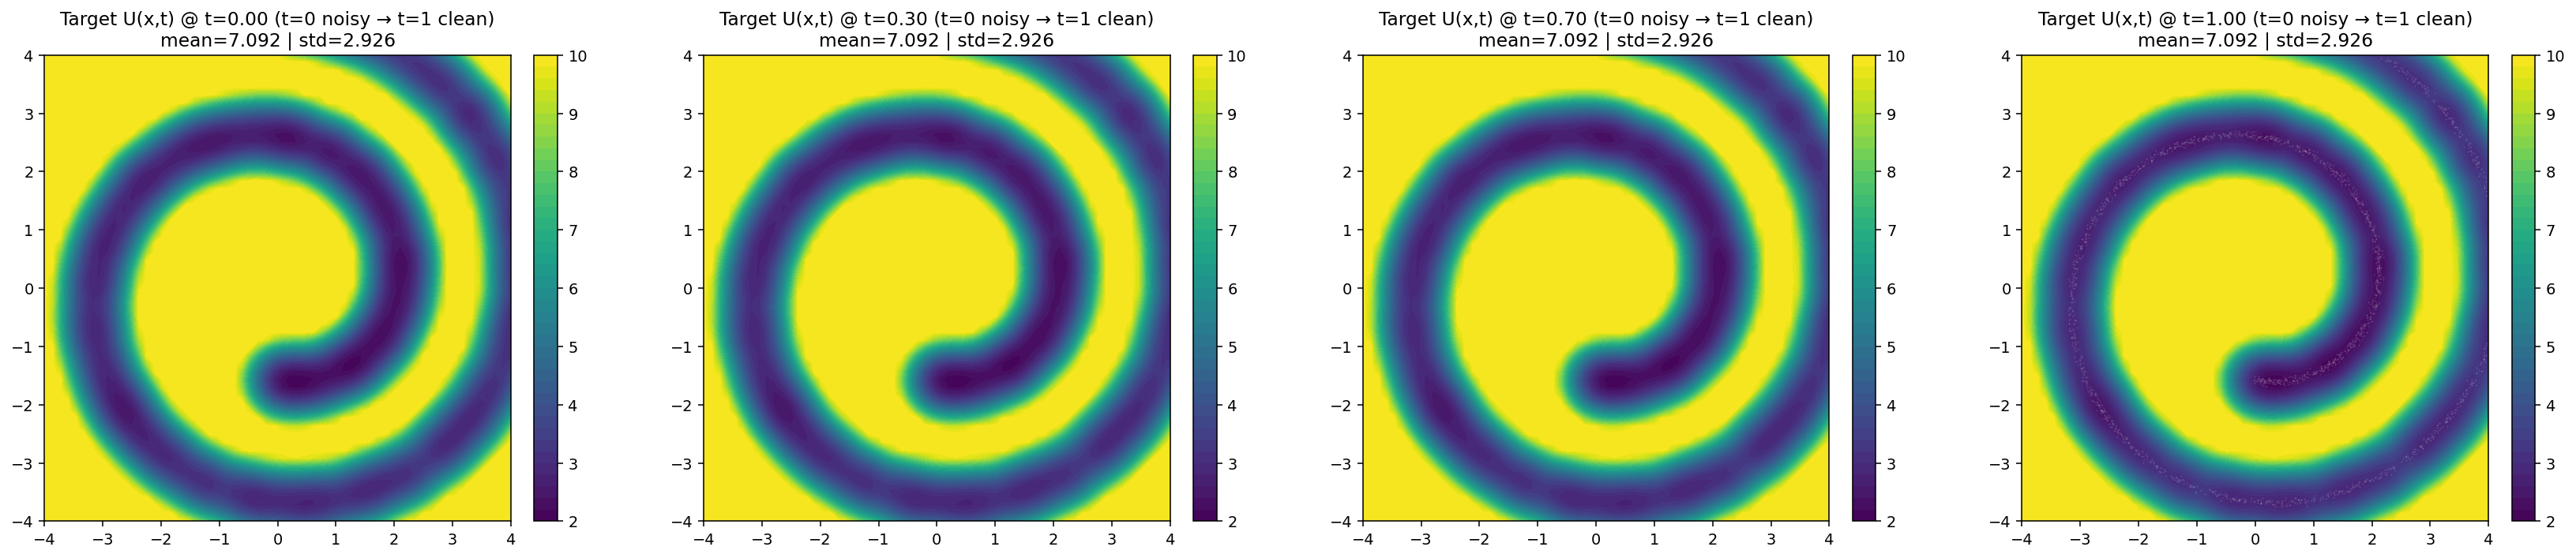

In [5]:
# --- Visualize target energy landscape at multiple smoothing steps (diffusion time) ---
#
# DrugFlow time convention: t=0 is *max noise* (most smoothed), t=1 is *clean* (least smoothed).
# We build a time-dependent KDE snapshot by:
#   centers(t) = alpha(t) * centers(clean)
#   bw(t)^2    = (alpha(t) * bw0)^2 + (sigma(t)^2 - sigma(1)^2)
# using the same (VE/VP) schedule as `model.module_x`.

@torch.no_grad()
def gaussian_mixture_energy_2d(
    x_query: torch.Tensor,          # (M,2)
    centers: torch.Tensor,          # (N,2)
    *,
    bandwidth: float,
) -> torch.Tensor:
    """Negative log KDE density for an isotropic Gaussian mixture."""
    if x_query.ndim != 2 or x_query.shape[1] != 2:
        raise ValueError(f"x_query must have shape (M,2); got {tuple(x_query.shape)}")
    if centers.ndim != 2 or centers.shape[1] != 2:
        raise ValueError(f"centers must have shape (N,2); got {tuple(centers.shape)}")

    bw = float(bandwidth)
    if not (bw > 0.0):
        raise ValueError(f"bandwidth must be positive; got {bw}")

    x = x_query[:, None, :]              # (M,1,2)
    c = centers[None, :, :]              # (1,N,2)
    d2 = torch.sum((x - c) ** 2, dim=-1) # (M,N)

    # log p(x) = log(1/N * sum_i exp(-||x-c_i||^2/(2 bw^2))) + const
    log_k = -0.5 * d2 / (bw * bw)
    log_norm = -np.log(centers.shape[0]) - np.log(2.0 * np.pi * bw * bw)
    log_p = torch.logsumexp(log_k, dim=1) + float(log_norm)
    return (-log_p).reshape(-1, 1)


@torch.no_grad()
def target_energy_grid_at_t(*, t_val: float, clip_max: float | None = None) -> np.ndarray:
    """Return the time-dependent target energy grid U_true(x,t) as (grid_size, grid_size)."""
    if 'ref' not in globals():
        raise RuntimeError("`ref` not found. Run Cell 4 first.")
    centers_clean = torch.as_tensor(ref, device=device, dtype=torch.float32)
    bw0 = float(bandwidth)

    t_tensor = torch.as_tensor([[float(t_val)]], device=device, dtype=torch.float32)
    alpha_t = float(model.module_x.alpha(t_tensor).view(-1)[0].item())
    sigma_t = float(model.module_x.sigma(t_tensor).view(-1)[0].item())
    sigma_clean = float(model.module_x.sigma(torch.ones((1, 1), device=device, dtype=torch.float32)).view(-1)[0].item())

    var_added = max(0.0, sigma_t * sigma_t - sigma_clean * sigma_clean)
    bw_t = float(np.sqrt((alpha_t * bw0) ** 2 + var_added))
    centers_t = centers_clean * float(alpha_t)

    u = gaussian_mixture_energy_2d(grid_tensor, centers_t, bandwidth=bw_t)
    u_np = u.detach().cpu().numpy().reshape(grid_size, grid_size)
    if clip_max is not None:
        u_np = np.clip(u_np, a_min=None, a_max=float(clip_max))
    return u_np


@torch.no_grad()
def plot_target_energy_smoothing(*, times: list[float], clip_max: float = 10.0):
    fig, axes = plt.subplots(1, len(times), figsize=(6 * len(times), 5), dpi=140)
    if len(times) == 1:
        axes = [axes]

    for ax, t_val in zip(axes, times):
        u_np = target_energy_grid_at_t(t_val=float(t_val), clip_max=clip_max)
        u_mean = float(np.mean(u_np))
        u_std = float(np.std(u_np))
        cp = ax.contourf(xx, yy, u_np, levels=40, cmap="viridis")

        # IMPORTANT: `ref` is the clean data distribution; only overlay it at t=1.0.
        if abs(float(t_val) - 1.0) < 1e-6:
            ax.scatter(ref[:, 0], ref[:, 1], s=1, c="white", alpha=0.15, linewidths=0)

        ax.set_title(
            f"Target U(x,t) @ t={t_val:.2f} (t=0 noisy → t=1 clean)\n"
            f"mean={u_mean:.3f} | std={u_std:.3f}"
        )
        ax.set_aspect("equal")
        ax.set_xlim(-grid_limit, grid_limit)
        ax.set_ylim(-grid_limit, grid_limit)
        fig.colorbar(cp, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


# Pick the same times you use later for learned-energy plots.
# Reminder: smaller t -> more noise -> smoother target.
target_times = [0.0, 0.3, 0.7, 1.0]
plot_target_energy_smoothing(times=target_times, clip_max=10.0)


KeyboardInterrupt: 

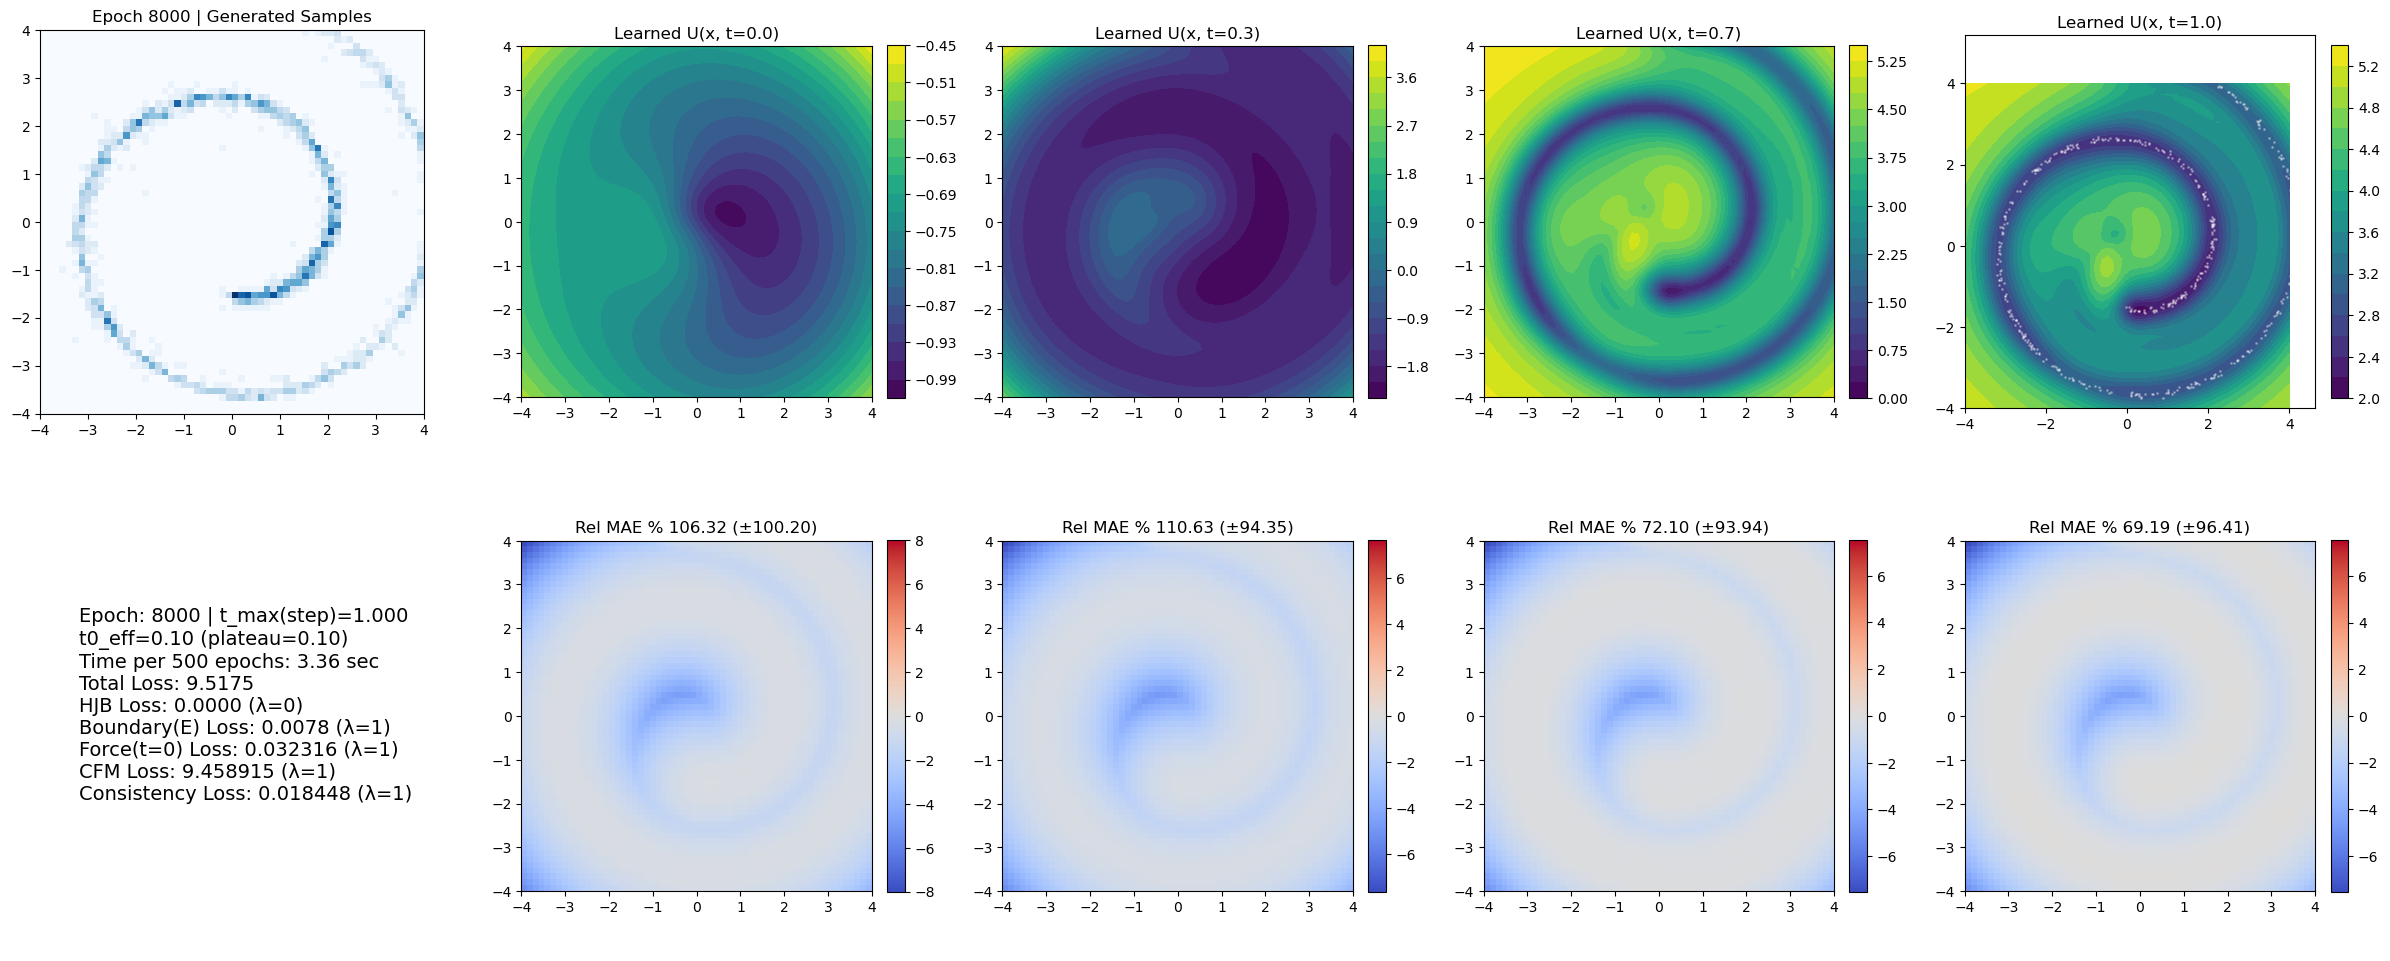

In [6]:
# --- Training loop with live plotting (matches the requested layout) ---
num_epochs = 10000
batch_size = 514      # number of 1-node graphs per step
lambda_hjb = float(cfg['loss_params'].lambda_hjb)
lambda_cons = float(cfg['loss_params'].lambda_consistency)
lambda_bound = float(cfg['loss_params'].lambda_energy)
lambda_force_t0 = float(getattr(cfg['loss_params'], 'lambda_force_t0', 0.0))
t0_batch_fraction = float(getattr(cfg['loss_params'], 't0_batch_fraction', 1.0))
lambda_x = float(cfg['loss_params'].lambda_x)
lambda_cfm = float(getattr(cfg['loss_params'], 'lambda_cfm', 0.0))

# Time-horizon curriculum settings (applied over batch steps).
schedule = str(getattr(cfg['simulation_params'], 'time_horizon_schedule', 'constant'))
warmup_frac = float(getattr(cfg['simulation_params'], 'time_horizon_warmup_fraction', 0.1))
plateau_frac = float(getattr(cfg['simulation_params'], 'time_horizon_plateau_start_fraction', 0.8))
t_sched_min = float(getattr(cfg['simulation_params'], 'time_horizon_t_min', 0.01))
t_sched_final = float(getattr(cfg['simulation_params'], 'time_horizon_t_final', 1.0))

def time_horizon_t_max_for_step(step: int, total_steps: int) -> float:
    """Notebook mirror of EnergyForceDiffusion's step-based sinusoidal schedule."""
    if total_steps <= 0:
        return float(t_sched_final)
    warmup_steps = int(total_steps * warmup_frac)
    plateau_steps = int(total_steps * plateau_frac)
    if plateau_steps <= warmup_steps:
        plateau_steps = warmup_steps + 1
    if step < warmup_steps:
        return float(t_sched_min)
    if step >= plateau_steps:
        return float(t_sched_final)
    current_step = step - warmup_steps
    total_growth_steps = plateau_steps - warmup_steps
    progress = float(current_step) / float(total_growth_steps)
    sine_factor = 0.5 * (1.0 - np.cos(progress * np.pi))
    return float(t_sched_min) + (float(t_sched_final) - float(t_sched_min)) * float(sine_factor)

times_to_plot = [0.0, 0.3, 0.7, 1.0]
titles = ['t=0.0', 't=0.3', 't=0.7', 't=1.0']
plot_every = 500
loss_history = []
loss_hjb_hist = []
loss_cons_hist = []
loss_bound_hist = []
loss_force_t0_hist = []
loss_cfm_hist = []
t_max_hist = []

epoch_time = 0.0
n_epochs_times = []

allowed_z = list(getattr(cfg['train_params'], 'pkl_allowed_atomic_numbers', [1, 6, 7, 8, 9]))
atom_nf = len(allowed_z)
carbon_idx = allowed_z.index(6) if 6 in allowed_z else 0

# If we're training with denoising/CFM losses (lambda_x > 0 or lambda_cfm > 0),
# then `ligand['x']` must be drawn from the true data distribution (swiss roll),
# because compute_loss will treat it as the clean sample x_0.
# Otherwise, keep the original uniform collocation sampling behavior unchanged.
use_data_as_clean = ((lambda_x > 0.0) or (lambda_cfm > 0.0))
ref_tensor = None
if use_data_as_clean:
    if 'ref' not in globals():
        raise RuntimeError("`ref` not found. Run Cell 4 (Target landscape + grid) before training.")
    ref_tensor = torch.as_tensor(ref, device=device, dtype=torch.float32)  # (N_ref, 2)

# This notebook loop runs one optimization step per iteration -> steps_per_epoch = 1.
steps_per_epoch = 1
total_steps = int(num_epochs * steps_per_epoch)

print('--- Starting 2D HJB Training (Swiss Roll) ---')
print('hjb_eval_points =', getattr(cfg['loss_params'], 'hjb_eval_points', 'noisy'))
print('time_horizon_schedule =', schedule)
print('lambda_force_t0 =', lambda_force_t0)
print('t0_batch_fraction (plateau) =', t0_batch_fraction)
print('t0_fraction schedule: linear 1.0 -> plateau over warmup_frac =', warmup_frac)
for epoch in range(num_epochs):
    start_time = time.time()
    optimizer.zero_grad(set_to_none=True)

    # 1) Sample clean points x from data distribution if denoising/CFM losses are active,
    #    else uniform collocation points.
    if use_data_as_clean:
        assert ref_tensor is not None
        idx = torch.randint(0, ref_tensor.shape[0], (batch_size,), device=device)
        x_train = ref_tensor[idx]  # (B,2) swiss-roll samples
    else:
        x_train = (torch.rand(batch_size, 2, device=device) * 8.0) - 4.0  # uniform in [-4,4]^2

    # 2) Sample diffusion time with optional curriculum over *batch steps*.
    #    t is in diffusion time: t=0 clean -> t=1 noisy.
    step = int(epoch * steps_per_epoch)
    if schedule == 'sinusoidal':
        t_max = time_horizon_t_max_for_step(step=step, total_steps=total_steps)
        t_max = float(np.clip(t_max, 0.0, 1.0))
        t_min = float(np.clip(t_sched_min, 0.0, t_max))
        t_train = torch.rand(batch_size, 1, device=device) * (t_max - t_min) + t_min
    else:
        t_max = 1.0
        t_train = torch.rand(batch_size, 1, device=device)
    t_max_hist.append(float(t_max))

    # 3) Uniform temperature per example (requires conditioning enabled)
    if model.use_temperature:
        temperature_train = torch.empty(batch_size, 1, device=device).uniform_(
            float(cfg['simulation_params'].temperature_min),
            float(cfg['simulation_params'].temperature_max),
        )
    else:
        temperature_train = None

    # 4) Build ligand batch: each point is a 1-node graph
    ligand = make_ligand_from_points(
        xy=x_train,
        t_batch_size=batch_size,
        atom_nf=atom_nf,
        carbon_idx=carbon_idx,
        device=device,
    )

    # 5) Boundary targets per-graph (each graph is a single node)
    # NOTE: For plotting we use a time-dependent target surface; training uses the static Gaussian-mixture energy.
    energy_tgt = target_landscape.node_energy(x_train).view(-1)  # (B,)

    force_tgt = None
    if float(lambda_force_t0) > 0.0:
        # (B,2) for 1-node graphs; compute_loss expects per-node forces.
        force_tgt = target_landscape.node_force(x_train)

    # 6) Compute repo loss (includes boundary + HJB + consistency + optional CFM)
    # NOTE: EnergyForceDiffusion.compute_loss will force a fraction of the batch to have t=0 for the boundary losses.
    # The t=0 fraction follows the new schedule: linear decay from 1.0 -> t0_batch_fraction over warmup_frac.
    loss, info = model.compute_loss(
        ligand,
        energy=energy_tgt,
        force=force_tgt,
        t=t_train,
        temperature=temperature_train,
        step=step,
        total_steps=total_steps,
        return_info=True,
    )

    # Note: compute_loss already applies lambdas internally; we also log components.
    loss_history.append(float(loss.detach().cpu().item()))
    loss_hjb_hist.append(float(info.get('loss_hjb', 0.0)))
    loss_cons_hist.append(float(info.get('loss_consistency', 0.0)))
    loss_bound_hist.append(float(info.get('loss_energy', 0.0)))
    loss_force_t0_hist.append(float(info.get('loss_force_t0', 0.0)))
    loss_cfm_hist.append(float(info.get('loss_cfm', 0.0)))

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()

    end_time = time.time()
    epoch_time = epoch_time + (end_time - start_time)

    if (epoch % plot_every) == 0:
        clear_output(wait=True)

        n_epochs_times.append(epoch_time)

        fig, axes = plt.subplots(2, 1 + len(times_to_plot), figsize=(24, 10))

        # A) Samples (Top-Left)
        model.eval()
        samp = model.sample_ligand(
            n_samples=2000,
            num_nodes=1,
            temperature=1.0,
            x_sampler='ode',
            h_sampler='markov_bridge',
            stochastic_x=False,
            stochastic_h=False,
        )
        samples_xy = samp['x'].detach().cpu().numpy()
        axes[0, 0].hist2d(samples_xy[:, 0], samples_xy[:, 1], bins=60, range=[[-4, 4], [-4, 4]], cmap='Blues')
        axes[0, 0].set_title(f'Epoch {epoch} | Generated Samples')
        axes[0, 0].set_aspect('equal')

        # B) Loss text (Bottom-Left)
        axes[1, 0].axis('off')
        avg_time = float(np.mean(n_epochs_times[1:])) if len(n_epochs_times) > 1 else float('nan')
        t0_eff = float(info.get('t0_batch_fraction_effective', float('nan')))
        info_text = (
            f'Epoch: {epoch} | t_max(step)={t_max_hist[-1]:.3f}\n' 
            f't0_eff={t0_eff:.2f} (plateau={t0_batch_fraction:.2f})\n'
            f'Time per {plot_every} epochs: {avg_time:.2f} sec\n'
            f'Total Loss: {loss_history[-1]:.4f}\n'
            f'HJB Loss: {loss_hjb_hist[-1]:.4f} (λ={lambda_hjb:g})\n'
            f'Boundary(E) Loss: {loss_bound_hist[-1]:.4f} (λ={lambda_bound:g})\n'
            f'Force(t=0) Loss: {loss_force_t0_hist[-1]:.6f} (λ={lambda_force_t0:g})\n'
            f'CFM Loss: {loss_cfm_hist[-1]:.6f} (λ={lambda_cfm:g})\n'
            f'Consistency Loss: {loss_cons_hist[-1]:.6f} (λ={lambda_cons:g})\n'
        )
        axes[1, 0].text(0.1, 0.5, info_text, fontsize=14, va='center')

        # Pre-calc learned energies and diffs to find global symmetric color scale.
        # IMPORTANT: compare to the time-dependent target surface U_true(x,t_val), not always the t=1 surface.
        plot_data = []
        diffs = []
        for t_val in times_to_plot:
            u_learned = predict_energy_grid(
                model,
                xy_grid=grid_tensor,
                grid_size=grid_size,
                allowed_z=allowed_z,
                t_val=float(t_val),
                temperature=1.0,
            )
            u_true = target_energy_grid_at_t(t_val=float(t_val), clip_max=None)
            u_diff = (u_learned - u_true) / float(np.mean(u_true))
            plot_data.append((u_learned, u_diff))
            diffs.append(u_diff)

        # C) Plot learned energy (top row) + error (bottom row)
        for i, (u_learned_np, u_diff_np) in enumerate(plot_data):
            col = i + 1

            im1 = axes[0, col].contourf(xx, yy, u_learned_np, levels=20, cmap='viridis')
            axes[0, col].set_title(f'Learned U(x, {titles[i]})')
            axes[0, col].set_aspect('equal')
            fig.colorbar(im1, ax=axes[0, col], fraction=0.046, pad=0.04)

            # IMPORTANT: `ref` is the clean distribution; only overlay it on the t=1 plot.
            if abs(float(times_to_plot[i]) - 1.0) < 1e-6:
                axes[0, col].scatter(ref[:500, 0], ref[:500, 1], s=1, c='white', alpha=0.3)

            rel_max_abs_error = float(np.abs(diffs[i]).max())
            rel_mea = float(np.mean(np.abs(diffs[i])))
            rel_mae_std = float(np.std(diffs[i]))
            if rel_max_abs_error < 1e-3:
                rel_max_abs_error = 0.01

            im2 = axes[1, col].imshow(
                u_diff_np,
                extent=(-4, 4, -4, 4),
                origin='lower',
                cmap='coolwarm',
                vmin=-rel_max_abs_error,
                vmax=rel_max_abs_error,
            )
            axes[1, col].set_title(f'Rel MAE % {rel_mea*100:.2f} (±{np.abs(rel_mae_std)*100:.2f})')
            axes[1, col].set_aspect('equal')
            fig.colorbar(im2, ax=axes[1, col], fraction=0.046, pad=0.04)

        epoch_time = 0.0

        plt.tight_layout()
        display(fig)
        plt.close(fig)
        model.train()
        print(f'Epoch {epoch} | Loss: {loss_history[-1]:.4f}')

print('--- Training Finished ---')
plot_loss_curve(loss_history)

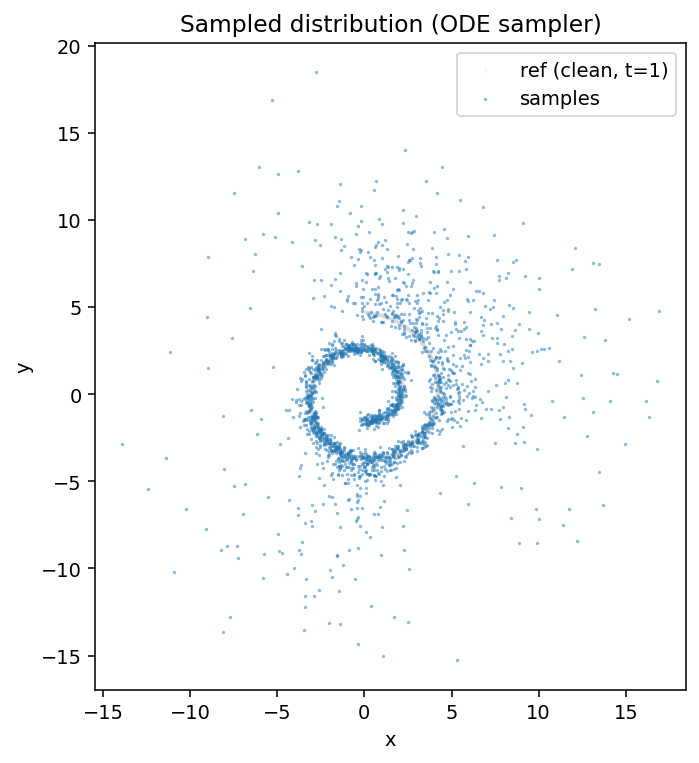

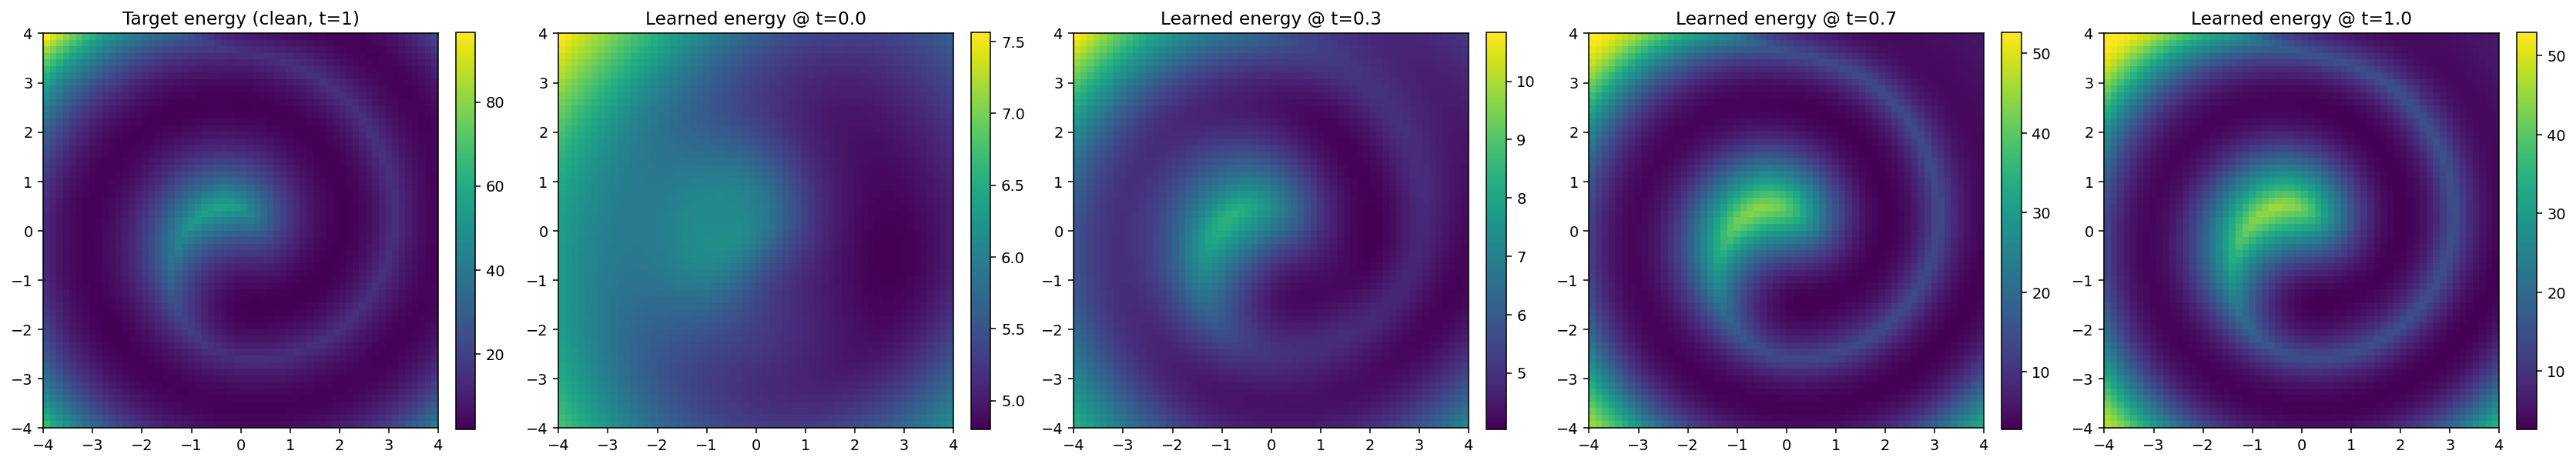

In [ ]:
# Post-training plots: sampled distribution + learned energy surfaces at t={0,0.3,0.7,1}
model.eval()
fig, ax = plt.subplots(1, 1, figsize=(7, 6), dpi=140)
samp = model.sample_ligand(
    n_samples=2000,
    num_nodes=1,
    temperature=1.0,
    temperature_sampler=1.0,
    x_sampler='ode',
    h_sampler='markov_bridge',
    stochastic_x=False,
    stochastic_h=False,
 )
xy = samp['x'].detach().cpu().numpy()
ax.scatter(ref[:, 0], ref[:, 1], s=3, c='0.85', alpha=0.25, linewidths=0, label='ref (clean, t=1)')
ax.scatter(xy[:, 0], xy[:, 1], s=3, alpha=0.5, linewidths=0, label='samples')
ax.set_title('Sampled distribution (ODE sampler)')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_aspect('equal', adjustable='box')
ax.legend()
plt.show()

fig, axes = plt.subplots(1, 1 + len(times_to_plot), figsize=(24, 5), dpi=140)

# Target: show clean (t=1) energy surface for reference
u_true_clean = target_energy_grid_at_t(t_val=1.0, clip_max=None)
im0 = axes[0].imshow(u_true_clean, origin='lower', extent=(-4,4,-4,4), cmap='viridis', aspect='equal')
axes[0].set_title('Target energy (clean, t=1)')
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

for i, t_val in enumerate(times_to_plot):
    u_learned = predict_energy_grid(
        model,
        xy_grid=grid_tensor,
        grid_size=grid_size,
        allowed_z=allowed_z,
        t_val=float(t_val),
        temperature=1.0,
    )
    im = axes[i + 1].imshow(u_learned, origin='lower', extent=(-4,4,-4,4), cmap='viridis', aspect='equal')
    axes[i + 1].set_title(f'Learned energy @ t={float(t_val):.1f}')
    plt.colorbar(im, ax=axes[i + 1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

## Task 4 — Boltzmann Distribution Analysis
We sample a larger distribution of molecules and analyze if they follow the Boltzmann distribution $p(x) \propto e^{-U(x)}$.
We verify this by:
1. Comparing the histogram of energies $U(x)$ for generated samples vs. ground truth data.
2. Visualizing the spatial overlap.
If the histograms match, the model has successfully learned the equilibrium statistics of the potential surface.

Sampling 4096 molecules for analysis...


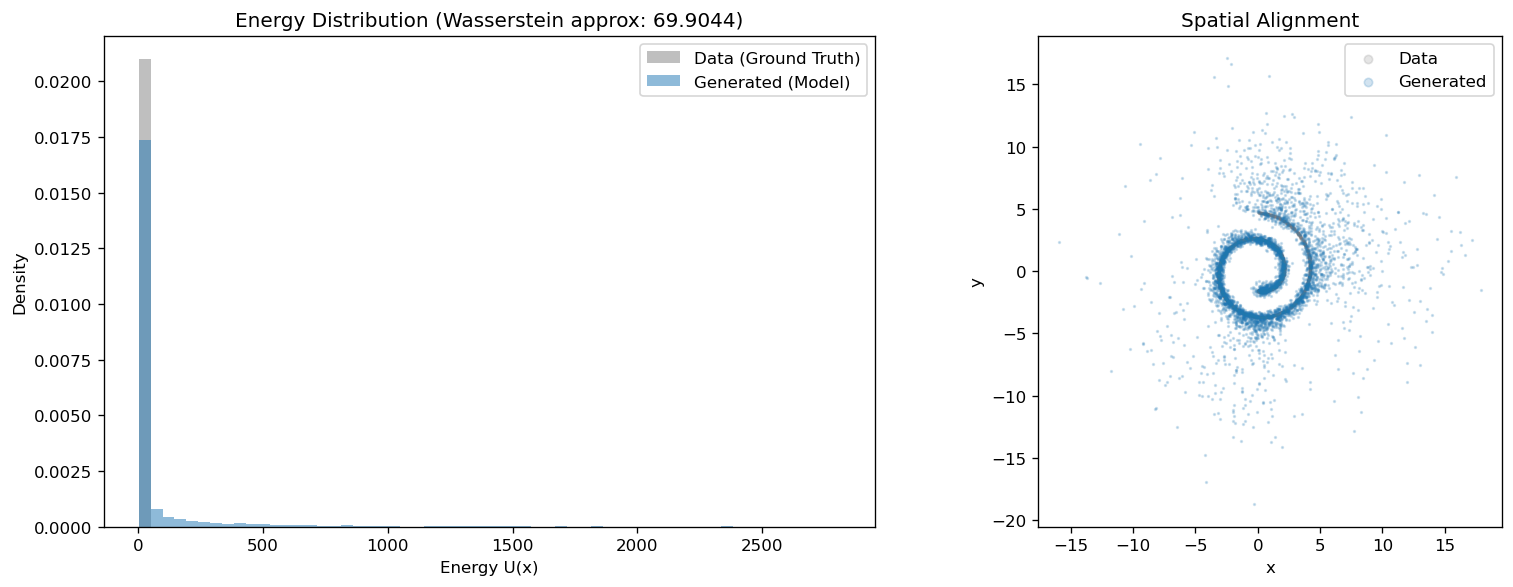

In [ ]:
# Task 4: Boltzmann Distribution Analysis
# We sample a large batch of molecules and compare their energy distribution to the ground truth.

n_samples = 4096
# We use a larger batch for better statistics.
print(f"Sampling {n_samples} molecules for analysis...")

model.eval()
with torch.no_grad():
    # Helper to sample in batches if needed, but 4096 usually fits in GPU memory for 2D data
    samp = model.sample_ligand(
        n_samples=n_samples,
        num_nodes=1,
        temperature=1.0,
        x_sampler='ode',   # ODE flow maps prior -> data distribution deterministicly
        h_sampler='markov_bridge',
        stochastic_x=False,
        stochastic_h=False,
    )
    samples_xy = samp['x'] # Keep on device

# 1. Compute U_target for all generated samples
# target_landscape was defined in the Data setup cell
u_samples = target_landscape.node_energy(samples_xy).cpu().numpy().flatten()

# 2. Compute U_target for ground truth samples (ref) for comparison
ref_tensor_eval = torch.as_tensor(ref, device=device, dtype=torch.float32)
u_ref = target_landscape.node_energy(ref_tensor_eval).cpu().numpy().flatten()

# 3. Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=120)

# Histogram of Energies
# If the model learns the density p(x) ~ exp(-U(x)), the histogram of energies 
# on generated samples should match the histogram of energies on data samples.
# (Note: p(E) depends on density of states, so we compare directly to data).
bins = np.linspace(min(u_samples.min(), u_ref.min()), max(u_samples.max(), u_ref.max()), 60)
ax1.hist(u_ref, bins=bins, alpha=0.5, density=True, label='Data (Ground Truth)', color='gray')
ax1.hist(u_samples, bins=bins, alpha=0.5, density=True, label='Generated (Model)', color='tab:blue')
ax1.set_xlabel('Energy U(x)')
ax1.set_ylabel('Density')
ax1.set_title(f'Energy Distribution (Wasserstein approx: {np.abs(u_ref.mean() - u_samples.mean()):.4f})')
ax1.legend()

# Spatial Scatter
samples_np = samples_xy.cpu().numpy()
ax2.scatter(ref[:, 0], ref[:, 1], s=1, c='gray', alpha=0.2, label='Data')
ax2.scatter(samples_np[:, 0], samples_np[:, 1], s=1, c='tab:blue', alpha=0.2, label='Generated')
ax2.set_title('Spatial Alignment')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_aspect('equal')
ax2.legend(markerscale=5.0)

plt.tight_layout()
plt.show()

# Optional: Decay analysis
# For a simple harmonic oscillator, log N(E) vs E is linear. 
# For complex landscapes, it's non-trivial, but the overlap above is the gold standard.
